# Library

In [ ]:
# import sys
# !{sys.executable} -m pip install tensorflow-macos


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 MB 26.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 46.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 37.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 52.1 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions-4.11.0


In [54]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import IncrementalPCA
import time
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Importing Dataset

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [146]:
df = pd.read_csv("final-Project.csv", on_bad_lines='skip')

# PreProcessing

## Initial Exploration

Before any processing, we inspect the structure of the dataset:
- Total rows and columns
- Column names and data types
- Missing value counts

The dataset is **bilingual** (English/French), containing duplicate columns
for most features. French-language duplicates will be removed in the next step.


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350361 entries, 0 to 350360
Data columns (total 21 columns):
 #   Column                                                       Non-Null Count   Dtype 
---  ------                                                       --------------   ----- 
 0   Numéro d'identification / Number ID                          350361 non-null  int64 
 1   Date Received / Date reçue                                   350361 non-null  object
 2   Complaint Received Type                                      350361 non-null  object
 3   Type de plainte reçue                                        350361 non-null  object
 4   Country                                                      350361 non-null  object
 5   Pays                                                         350361 non-null  object
 6   Province/State                                               350361 non-null  object
 7   Province/État                                                350361 non-nu

In [148]:
df.isnull().sum()

Numéro d'identification / Number ID                            0
Date Received / Date reçue                                     0
Complaint Received Type                                        0
Type de plainte reçue                                          0
Country                                                        0
Pays                                                           0
Province/State                                                 0
Province/État                                                  0
Fraud and Cybercrime Thematic Categories                       0
Catégories thématiques sur la fraude et la cybercriminalité    0
Solicitation Method                                            0
Méthode de sollicitation                                       0
Gender                                                         0
Genre                                                          0
Language of Correspondence                                     0
Langue de correspondance 

In [149]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350361 entries, 0 to 350360
Data columns (total 21 columns):
 #   Column                                                       Non-Null Count   Dtype 
---  ------                                                       --------------   ----- 
 0   Numéro d'identification / Number ID                          350361 non-null  int64 
 1   Date Received / Date reçue                                   350361 non-null  object
 2   Complaint Received Type                                      350361 non-null  object
 3   Type de plainte reçue                                        350361 non-null  object
 4   Country                                                      350361 non-null  object
 5   Pays                                                         350361 non-null  object
 6   Province/State                                               350361 non-null  object
 7   Province/État                                                350361 non-nu

In [150]:
df['Number of Victims / Nombre de victimes'] = df['Number of Victims / Nombre de victimes'].fillna(0).astype(int)
df['Dollar Loss /pertes financières'] = df['Dollar Loss /pertes financières'].replace({r'[$,]': ''}, regex=True).astype(float)
df

,Numéro d'identification / Number ID,Date Received / Date reçue,Complaint Received Type,Type de plainte reçue,Country,Pays,Province/State,Province/État,Fraud and Cybercrime Thematic Categories,Catégories thématiques sur la fraude et la cybercriminalité,...,Méthode de sollicitation,Gender,Genre,Language of Correspondence,Langue de correspondance,Victim Age Range / Tranche d'âge des victimes,Complaint Type,Type de plainte,Number of Victims / Nombre de victimes,Dollar Loss /pertes financières
0,350308,2025-09-29,Phone,Téléphone,Canada,Canada,Ontario,Ontario,Personal Info,Renseignements personnels,...,Appel direct,Female,Femme,English,Anglais,'30 - 39,Victim,Victime,1,0.0
1,350309,2025-09-29,Phone,Téléphone,Canada,Canada,Quebec,Québec,Identity Fraud,Fraude à l'identité,...,Autre/inconnu,Male,Homme,English,Anglais,'50 - 59,Victim,Victime,1,0.0
2,350310,2025-09-29,Phone,Téléphone,Canada,Canada,Quebec,Québec,Extortion,Extorsion,...,Appel direct,Female,Femme,French,Français,'20 - 29,Attempt,Tentative,0,0.0
3,350311,2025-09-29,Phone,Téléphone,Canada,Canada,Ontario,Ontario,Identity Fraud,Fraude à l'identité,...,Autre/inconnu,Female,Femme,English,Anglais,'40 - 49,Victim,Victime,1,0.0
4,350312,2025-09-29,Phone,Téléphone,Canada,Canada,Manitoba,Manitoba,Identity Fraud,Fraude à l'identité,...,Autre/inconnu,Female,Femme,English,Anglais,'60 - 69,Victim,Victime,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350356,68,2021-01-02,CAFC Website,CAFC site web,Canada,Canada,British Columbia,Colombie-Britanique,Identity Fraud,Fraude à l'identité,...,Autre/inconnu,Male,Homme,English,Anglais,'50 - 59,Victim,Victime,1,0.0
350357,69,2021-01-02,CAFC Website,CAFC site web,Not Specified,Non spécifié,Not Specified,Non spécifié,Phishing,Hameçonnage,...,Messages texte,Not Available,non disponible,Not Available,non disponible,'Not Available / non disponible,Attempt,Tentative,0,0.0
350358,70,2021-01-02,CAFC Website,CAFC site web,Canada,Canada,Quebec,Québec,"Emergency (Jail, Accident, Hospital, Help)","Urgence (Arrestation, Accident, Hospitalisatio...",...,Courriel,Male,Homme,English,Anglais,'50 - 59,Victim,Victime,1,700.0
350359,71,2021-01-02,CAFC Website,CAFC site web,Not Specified,Non spécifié,Not Specified,Non spécifié,Extortion,Extorsion,...,Porte-à-porte/en personne,Not Available,non disponible,Not Available,non disponible,'Not Available / non disponible,Victim,Victime,1,180.0


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350361 entries, 0 to 350360
Data columns (total 21 columns):
 #   Column                                                       Non-Null Count   Dtype  
---  ------                                                       --------------   -----  
 0   Numéro d'identification / Number ID                          350361 non-null  int64  
 1   Date Received / Date reçue                                   350361 non-null  object 
 2   Complaint Received Type                                      350361 non-null  object 
 3   Type de plainte reçue                                        350361 non-null  object 
 4   Country                                                      350361 non-null  object 
 5   Pays                                                         350361 non-null  object 
 6   Province/State                                               350361 non-null  object 
 7   Province/État                                                3503

In [152]:
df.columns

Index(['Numéro d'identification / Number ID', 'Date Received / Date reçue',
       'Complaint Received Type', 'Type de plainte reçue', 'Country', 'Pays',
       'Province/State', 'Province/État',
       'Fraud and Cybercrime Thematic Categories',
       'Catégories thématiques sur la fraude et la cybercriminalité',
       'Solicitation Method', 'Méthode de sollicitation', 'Gender', 'Genre',
       'Language of Correspondence', 'Langue de correspondance',
       'Victim Age Range / Tranche d'âge des victimes', 'Complaint Type',
       'Type de plainte', 'Number of Victims / Nombre de victimes',
       'Dollar Loss /pertes financières'],
      dtype='object')

In [153]:
df = df.rename(columns={
    "Numéro d'identification / Number ID": "Number ID",
    "Date Received / Date reçue": "Date Received",
    "Victim Age Range / Tranche d'âge des victimes" : "Victim Age Range",
    "Number of Victims / Nombre de victimes":"Number of Victims",
    "Dollar Loss /pertes financières": "Dollar Loss"
})
display(df.head())

,Number ID,Date Received,Complaint Received Type,Type de plainte reçue,Country,Pays,Province/State,Province/État,Fraud and Cybercrime Thematic Categories,Catégories thématiques sur la fraude et la cybercriminalité,...,Méthode de sollicitation,Gender,Genre,Language of Correspondence,Langue de correspondance,Victim Age Range,Complaint Type,Type de plainte,Number of Victims,Dollar Loss
0,350308,2025-09-29,Phone,Téléphone,Canada,Canada,Ontario,Ontario,Personal Info,Renseignements personnels,...,Appel direct,Female,Femme,English,Anglais,'30 - 39,Victim,Victime,1,0.0
1,350309,2025-09-29,Phone,Téléphone,Canada,Canada,Quebec,Québec,Identity Fraud,Fraude à l'identité,...,Autre/inconnu,Male,Homme,English,Anglais,'50 - 59,Victim,Victime,1,0.0
2,350310,2025-09-29,Phone,Téléphone,Canada,Canada,Quebec,Québec,Extortion,Extorsion,...,Appel direct,Female,Femme,French,Français,'20 - 29,Attempt,Tentative,0,0.0
3,350311,2025-09-29,Phone,Téléphone,Canada,Canada,Ontario,Ontario,Identity Fraud,Fraude à l'identité,...,Autre/inconnu,Female,Femme,English,Anglais,'40 - 49,Victim,Victime,1,0.0
4,350312,2025-09-29,Phone,Téléphone,Canada,Canada,Manitoba,Manitoba,Identity Fraud,Fraude à l'identité,...,Autre/inconnu,Female,Femme,English,Anglais,'60 - 69,Victim,Victime,1,0.0


# Column Renaming
## Initial Exploration

Before any processing, we inspect the structure of the dataset:
- Total rows and columns
- Column names and data types
- Missing value counts

The dataset is **bilingual** (English/French), containing duplicate columns
for most features. French-language duplicates will be removed in the next step.
##  Column Renaming & Cleaning

Key columns are renamed for readability. French-language duplicate columns
(`Pays`, `Genre`, `Type de plainte`, etc.) are dropped, as they carry
identical information to their English counterparts.

The `Victim Age Range` column contains a leading apostrophe artifact (`'30 - 39`)
which is cleaned using `str.lstrip()`.


In [154]:
columns_to_drop = [
    'Pays',
    'Genre',
    'Type de plainte',
    'Province/État',
    'Catégories thématiques sur la fraude et la cybercriminalité',
    'Langue de correspondance',
    'Méthode de sollicitation',
    'Type de plainte reçue'
]

existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_columns_to_drop)

display(df.columns)

Index(['Number ID', 'Date Received', 'Complaint Received Type', 'Country',
       'Province/State', 'Fraud and Cybercrime Thematic Categories',
       'Solicitation Method', 'Gender', 'Language of Correspondence',
       'Victim Age Range', 'Complaint Type', 'Number of Victims',
       'Dollar Loss'],
      dtype='object')

In [155]:
df['Victim Age Range'] = df['Victim Age Range'].str.lstrip("' ")

In [156]:
df

,Number ID,Date Received,Complaint Received Type,Country,Province/State,Fraud and Cybercrime Thematic Categories,Solicitation Method,Gender,Language of Correspondence,Victim Age Range,Complaint Type,Number of Victims,Dollar Loss
0,350308,2025-09-29,Phone,Canada,Ontario,Personal Info,Direct call,Female,English,30 - 39,Victim,1,0.0
1,350309,2025-09-29,Phone,Canada,Quebec,Identity Fraud,Other/unknown,Male,English,50 - 59,Victim,1,0.0
2,350310,2025-09-29,Phone,Canada,Quebec,Extortion,Direct call,Female,French,20 - 29,Attempt,0,0.0
3,350311,2025-09-29,Phone,Canada,Ontario,Identity Fraud,Other/unknown,Female,English,40 - 49,Victim,1,0.0
4,350312,2025-09-29,Phone,Canada,Manitoba,Identity Fraud,Other/unknown,Female,English,60 - 69,Victim,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
350356,68,2021-01-02,CAFC Website,Canada,British Columbia,Identity Fraud,Other/unknown,Male,English,50 - 59,Victim,1,0.0
350357,69,2021-01-02,CAFC Website,Not Specified,Not Specified,Phishing,Text message,Not Available,Not Available,Not Available / non disponible,Attempt,0,0.0
350358,70,2021-01-02,CAFC Website,Canada,Quebec,"Emergency (Jail, Accident, Hospital, Help)",Email,Male,English,50 - 59,Victim,1,700.0
350359,71,2021-01-02,CAFC Website,Not Specified,Not Specified,Extortion,Door to door/in person,Not Available,Not Available,Not Available / non disponible,Victim,1,180.0


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350361 entries, 0 to 350360
Data columns (total 13 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   Number ID                                 350361 non-null  int64  
 1   Date Received                             350361 non-null  object 
 2   Complaint Received Type                   350361 non-null  object 
 3   Country                                   350361 non-null  object 
 4   Province/State                            350361 non-null  object 
 5   Fraud and Cybercrime Thematic Categories  350361 non-null  object 
 6   Solicitation Method                       350361 non-null  object 
 7   Gender                                    350361 non-null  object 
 8   Language of Correspondence                350361 non-null  object 
 9   Victim Age Range                          350361 non-null  object 
 10  Complaint Type      

In [158]:
df.describe()

,Number ID,Number of Victims,Dollar Loss
count,350361.000000,350361.000000,3.503610e+05
mean,175181.000000,0.649076,7.670432e+03
std,101140.653169,0.477260,1.029056e+05
min,1.000000,0.000000,0.000000e+00
25%,87591.000000,0.000000,0.000000e+00
50%,175181.000000,1.000000,0.000000e+00
75%,262771.000000,1.000000,0.000000e+00
max,350361.000000,1.000000,2.361500e+07


## Exploratory Data Analysis (EDA)

This section visualizes the key distributions and relationships in the dataset
to understand patterns before building models.

Charts included:
1. Distribution of Dollar Loss
2. Cases by Province/State
3. Victim Age Range distribution
4. Solicitation Method breakdown
5. Top Complaint Types
6. Dollar Loss by Age Range (Boxplot)
7. Correlation Heatmap
8. Number of Victims vs Dollar Loss (Scatter)

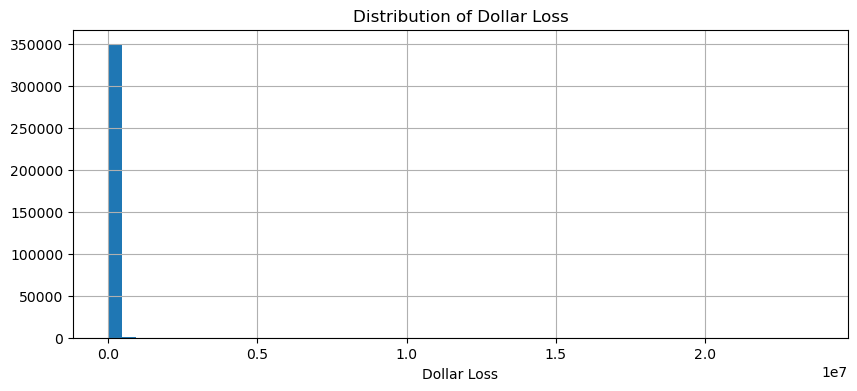

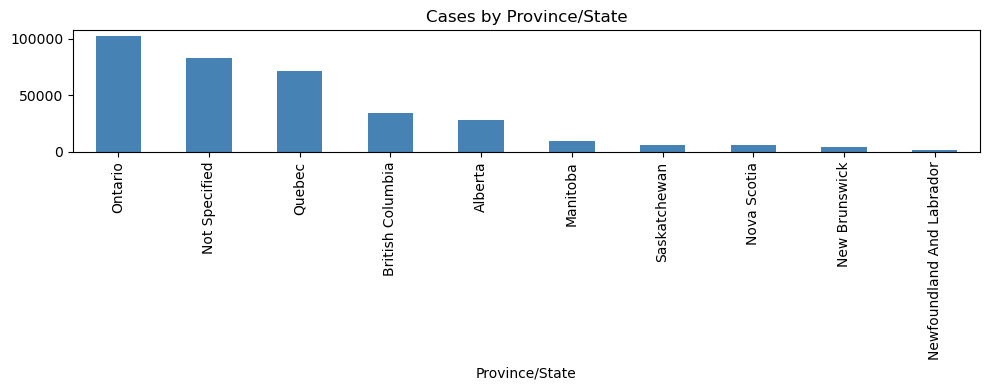

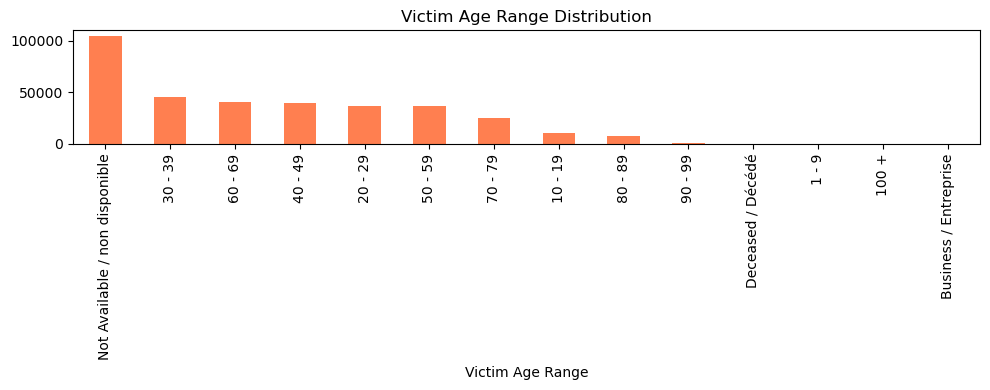

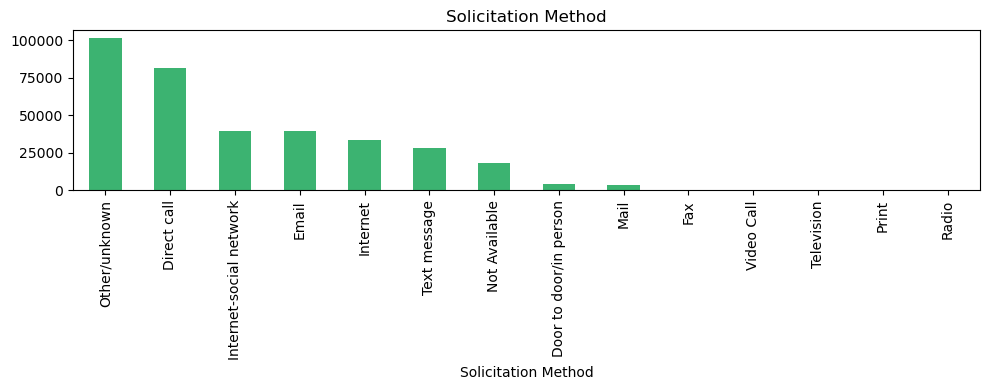

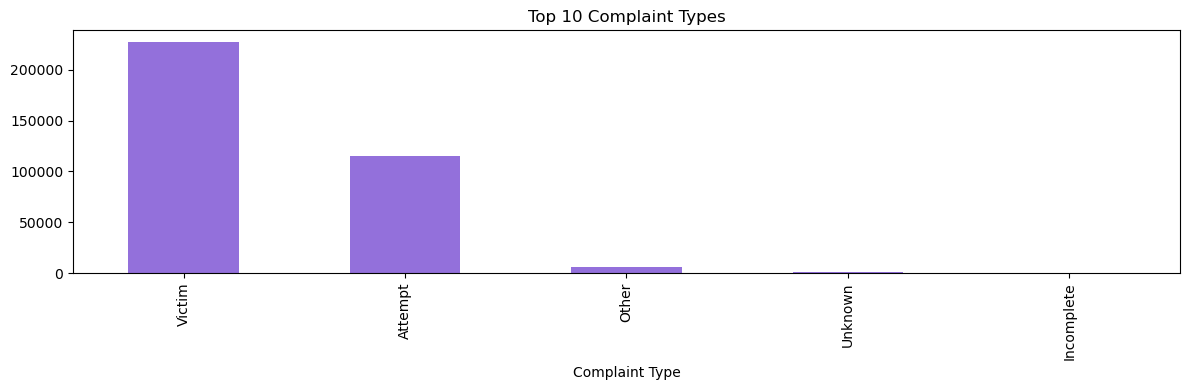

<Figure size 1200x500 with 0 Axes>

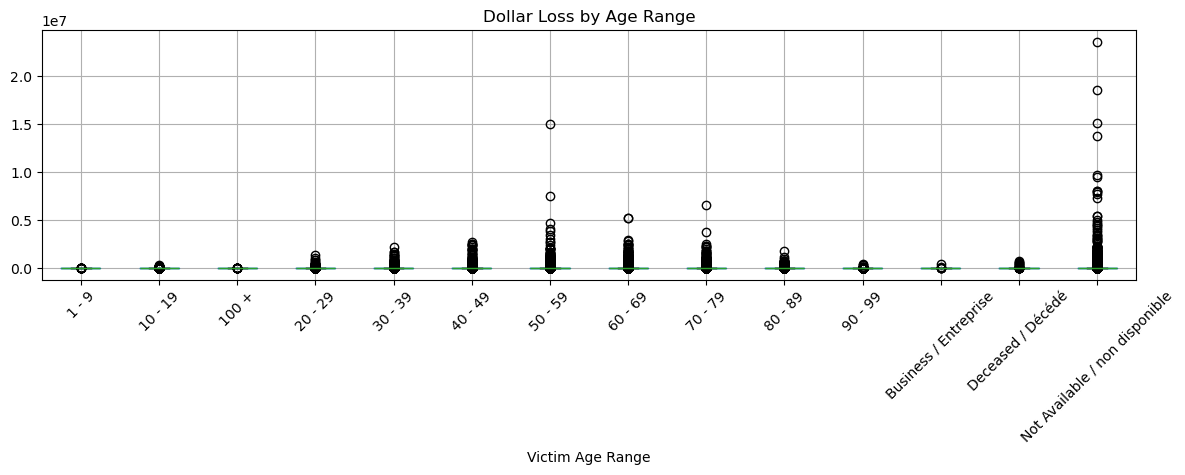

In [159]:


# ===== 1. Dollar Loss Distribution =====
plt.figure(figsize=(10,4))
df['Dollar Loss'].dropna().hist(bins=50)
plt.title('Distribution of Dollar Loss')
plt.xlabel('Dollar Loss')
plt.show()

# ===== 2. Top Provinces =====
df['Province/State'].value_counts().head(10).plot(kind='bar', figsize=(10,4), color='steelblue')
plt.title('Cases by Province/State')
plt.tight_layout()
plt.show()

# ===== 3. Victim Age Range ===== ye kari kon kho victim ro neshoun be!!!!!!!!!!
df['Victim Age Range'].value_counts().plot(kind='bar', figsize=(10,4), color='coral')
plt.title('Victim Age Range Distribution')
plt.tight_layout()
plt.show()

# ===== 4. Solicitation Method =====
if 'Solicitation Method' in df.columns:
    df['Solicitation Method'].value_counts().plot(kind='bar', figsize=(10,4), color='mediumseagreen')
    plt.title('Solicitation Method')
    plt.tight_layout()
    plt.show()

# ===== 5. Complaint Type =====
if 'Complaint Type' in df.columns:
    df['Complaint Type'].value_counts().head(10).plot(kind='bar', figsize=(12,4), color='mediumpurple')
    plt.title('Top 10 Complaint Types')
    plt.tight_layout()
    plt.show()

# ===== 6. Dollar Loss by Age Range (Boxplot) =====
plt.figure(figsize=(12,5))
df.dropna(subset=['Victim Age Range', 'Dollar Loss']).boxplot(
    column='Dollar Loss', by='Victim Age Range', figsize=(12,5)
)
plt.title('Dollar Loss by Age Range')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Scatter diagram

In [160]:
# #draw histogram of each feature
# df.hist(bins=50, figsize=(20,15))
# #save_fig("attribute_histogram_plots")
# plt.show()

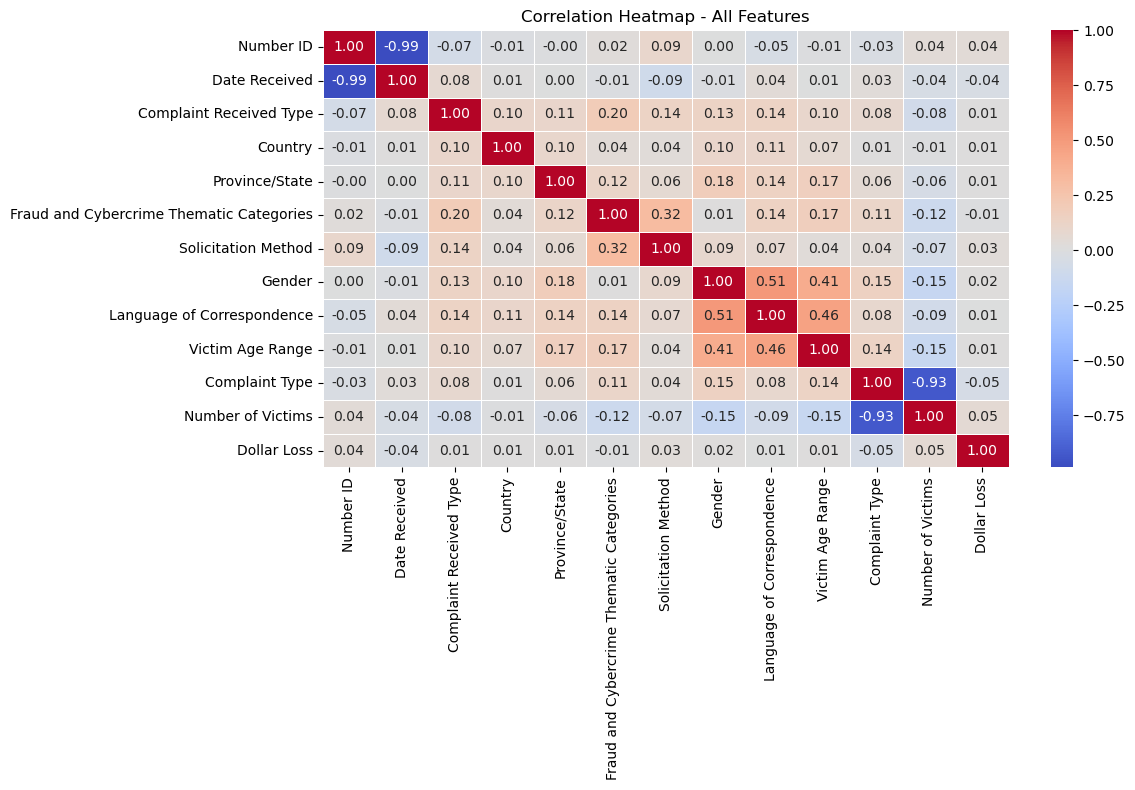

In [161]:
# ===== 7. Full Correlation Heatmap 
df_encoded = df.copy()
cat_cols = df_encoded.select_dtypes(include='object').columns

for col in cat_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

# just numeric columns
numeric_df = df_encoded.select_dtypes(include='number')

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - All Features')
plt.tight_layout()
plt.show()

## Date Feature Engineering

The `Date Received` column is parsed into structured time-based features:

| Feature | Description |
|---------|-------------|
| `Year` | Year the complaint was filed |
| `Month` | Month (1–12) |
| `DayOfWeek` | Day of week (0=Monday, 6=Sunday) |

These features allow the model to detect seasonal and temporal patterns
in fraud activity.

## Target Variable Engineering — `is_Victim`

The original `Complaint Type` column contains five categories:
`Victim`, `Attempt`, `Other`, `Unknown`, `Incomplete`.

A binary target variable `is_Victim` is created:
- `1` → Victim (complaint resulted in actual fraud)
- `0` → Attempt/Other (fraud was not completed)

**Class Distribution:**
- Victim (1): ~68.4%
- Attempt (0): ~31.6%

This moderate imbalance will be addressed during model training.
##  Missing Value Analysis

Many columns use placeholder strings (e.g., `"Not Available"`,
`"Other/unknown"`) instead of actual `NaN` values.

A custom `analyze_na()` function identifies both real nulls and
NA-like strings for each column, then recommends an action:

- **DROP**: column has > 26% missing → removed entirely
- **fillna**: column has < 26% missing → filled with `'Unknown'`

Result:
- `Solicitation Method` (35.8% missing) → **dropped**
- `Gender` (10.8% missing) → **filled**
- `Victim Age Range` (10.4% missing) → **filled**


In [162]:
print("data set beore encoding:", df.shape)

data set beore encoding: (350361, 13)


In [163]:
category_counts = df['Fraud and Cybercrime Thematic Categories'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']
print(category_counts.to_string(index=False))

                                  Category  Count
                            Identity Fraud  80073
                                 Extortion  32779
                                  Phishing  30138
                             Personal Info  28626
                                   Service  26962
                               Investments  20394
                               Merchandise  18420
                         Bank Investigator  15134
                                       Job  14195
                   Counterfeit Merchandise  13497
                                     Other  10675
                              Vendor Fraud  10101
                                   Unknown   9618
Emergency (Jail, Accident, Hospital, Help)   7979
                                   Romance   6779
                            Spear Phishing   6314
                                     Prize   4735
                             False Billing   2172
                            Recovery Pitch   2060


In [164]:
category_counts = df['Province/State'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']
print(category_counts.to_string(index=False))

                 Category  Count
                  Ontario 102210
            Not Specified  82484
                   Quebec  71813
         British Columbia  33958
                  Alberta  28044
                 Manitoba   9536
             Saskatchewan   6219
              Nova Scotia   5684
            New Brunswick   4668
Newfoundland And Labrador   2032
     Prince Edward Island    904
               California    652
                    Yukon    320
   North West Territories    206
                 New York    148
                  Florida    144
                    Texas    126
                  Nunavut    100
               Washington     92
            Massachusetts     65
                 Michigan     62
             Pennsylvania     61
                  Arizona     49
                 Illinois     49
                 Virginia     46
           North Carolina     45
                 Maryland     45
               New Jersey     45
                Minnesota     42
          

In [165]:
category_counts = df['Country'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']
print(category_counts.to_string(index=False))

                                  Category  Count
                                    Canada 266553
                             Not Specified  78765
                             United States   2399
                                     India    259
                            United Kingdom    168
                                    France    149
                                 Australia    124
                                  Pakistan     88
                      United Arab Emirates     86
                                    Mexico     85
                                   Germany     79
                                   Nigeria     69
                                     China     65
                               Philippines     57
                                    Brazil     43
                                Bangladesh     41
                              South Africa     35
                 Iran, Islamic Republic of     34
                                 Hong Kong     33


In [166]:
category_counts = df['Solicitation Method'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']
print(category_counts.to_string(index=False))

               Category  Count
          Other/unknown 101691
            Direct call  81723
Internet-social network  39565
                  Email  39304
               Internet  33356
           Text message  28227
          Not Available  18249
 Door to door/in person   4330
                   Mail   3444
                    Fax    173
             Video Call    142
             Television     84
                  Print     65
                  Radio      8


In [167]:
category_counts = df['Language of Correspondence'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']
print(category_counts.to_string(index=False))

     Category  Count
      English 193984
Not Available  90074
       French  66303


In [168]:
category_counts = df['Victim Age Range'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']
print(category_counts.to_string(index=False))

                      Category  Count
Not Available / non disponible 104676
                       30 - 39  45888
                       60 - 69  40389
                       40 - 49  40085
                       20 - 29  37165
                       50 - 59  36854
                       70 - 79  25233
                       10 - 19  10629
                       80 - 89   7961
                       90 - 99   1028
             Deceased / Décédé    188
                         1 - 9    174
                         100 +     64
         Business / Entreprise     27


In [169]:
category_counts = df['Complaint Type'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']
print(category_counts.to_string(index=False))

  Category  Count
    Victim 227411
   Attempt 114810
     Other   6469
   Unknown   1152
Incomplete    519


In [170]:
category_counts = df['Dollar Loss'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']
print(category_counts.to_string(index=False))

   Category  Count
       0.00 263516
    1000.00   1594
     500.00   1538
    2000.00   1163
     200.00   1095
     100.00   1071
   10000.00   1058
     300.00   1021
    3000.00    944
    5000.00    841
     400.00    730
    1500.00    668
     600.00    642
   20000.00    617
     250.00    609
      99.00    556
     150.00    554
     800.00    553
   15000.00    538
      50.00    537
    4000.00    520
   30000.00    510
    2500.00    497
    6000.00    497
     700.00    462
     350.00    457
    8000.00    455
    1200.00    429
   50000.00    423
     900.00    418
    9000.00    380
    7000.00    380
   12000.00    373
   25000.00    371
   40000.00    358
  100000.00    339
    1800.00    290
     120.00    286
    1600.00    282
     130.00    274
     450.00    265
   60000.00    264
    1300.00    258
    1100.00    245
    1400.00    245
     750.00    233
    3500.00    230
   11000.00    224
      80.00    220
   18000.00    212
   13000.00    211
      60.00 

In [171]:
df['Date Received'] = pd.to_datetime(
df['Date Received'], errors='coerce')
df['Year']       = df['Date Received'].dt.year
df['Month']      = df['Date Received'].dt.month
df['DayOfWeek']  = df['Date Received'].dt.dayofweek
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)

In [172]:
exclude_keywords = ['unknown', 'other', 'incomplete']
df = df[~df['Complaint Type'].astype(str).str.strip().str.lower().apply(
    lambda x: any(kw in x for kw in exclude_keywords)
)]

df['is_Victim'] = df['Complaint Type'].astype(str).str.strip().str.lower().apply(
    lambda x: 1 if any(k in x for k in ['victim', 'victime']) else 0
)

print(df['Complaint Type'].value_counts(dropna=False))
df.drop(columns=['Complaint Type', 'Is_Weekend'], inplace=True)
print(df['is_Victim'].value_counts())


Complaint Type
Victim     227411
Attempt    114810
Name: count, dtype: int64
is_Victim
1    227411
0    114810
Name: count, dtype: int64


/var/folders/j2/h4vx0kps61q_zfy2ms363w5w0000gn/T/ipykernel_5524/1920531771.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_Victim'] = df['Complaint Type'].astype(str).str.strip().str.lower().apply(
/var/folders/j2/h4vx0kps61q_zfy2ms363w5w0000gn/T/ipykernel_5524/1920531771.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Complaint Type', 'Is_Weekend'], inplace=True)


In [173]:
df

,Number ID,Date Received,Complaint Received Type,Country,Province/State,Fraud and Cybercrime Thematic Categories,Solicitation Method,Gender,Language of Correspondence,Victim Age Range,Number of Victims,Dollar Loss,Year,Month,DayOfWeek,is_Victim
0,350308,2025-09-29,Phone,Canada,Ontario,Personal Info,Direct call,Female,English,30 - 39,1,0.0,2025,9,0,1
1,350309,2025-09-29,Phone,Canada,Quebec,Identity Fraud,Other/unknown,Male,English,50 - 59,1,0.0,2025,9,0,1
2,350310,2025-09-29,Phone,Canada,Quebec,Extortion,Direct call,Female,French,20 - 29,0,0.0,2025,9,0,0
3,350311,2025-09-29,Phone,Canada,Ontario,Identity Fraud,Other/unknown,Female,English,40 - 49,1,0.0,2025,9,0,1
4,350312,2025-09-29,Phone,Canada,Manitoba,Identity Fraud,Other/unknown,Female,English,60 - 69,1,0.0,2025,9,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350356,68,2021-01-02,CAFC Website,Canada,British Columbia,Identity Fraud,Other/unknown,Male,English,50 - 59,1,0.0,2021,1,5,1
350357,69,2021-01-02,CAFC Website,Not Specified,Not Specified,Phishing,Text message,Not Available,Not Available,Not Available / non disponible,0,0.0,2021,1,5,0
350358,70,2021-01-02,CAFC Website,Canada,Quebec,"Emergency (Jail, Accident, Hospital, Help)",Email,Male,English,50 - 59,1,700.0,2021,1,5,1
350359,71,2021-01-02,CAFC Website,Not Specified,Not Specified,Extortion,Door to door/in person,Not Available,Not Available,Not Available / non disponible,1,180.0,2021,1,5,1


In [174]:
def clean_na(df, na_report, protect_cols=None):
    """
    Step 1 — Replace NA-like strings with actual NaN
    Step 2 — Drop rows that have > 1 NA
    Step 3 — fillna remaining (exactly 1 NA):
              categorical → mode
              numeric     → mean
    """
    if protect_cols is None:
        protect_cols = []

    df = df.copy()

    na_map = {
        'Solicitation Method':  ['Other/unknown', 'Not Available'],
        'Gender':               ['Not Available', 'Unknown',
                                 'Prefer not to say', 'Other'],
        'Language':             ['Not Available'],
        'Country':              ['Not Specified'],
        'Province':             ['Not Specified'],
        'Complaint Type':       ['Unknown', 'Incomplete', 'Other'],
        'Victim Age Range':     ['Not Available / non disponible',
                                 'Deceased / Décédé',
                                 'Business / Entreprise'],
    }

    # ── Step 1: Replace NA-like strings with NaN ──────────────────────
    for col, na_vals in na_map.items():
        if col in df.columns:
            df[col] = df[col].replace(na_vals, np.nan)

    # ── Step 2: Drop rows with > 1 NA ─────────────────────────────────
    na_per_row = df.isnull().sum(axis=1)
    rows_to_drop = (na_per_row > 1).sum()
    df = df[na_per_row <= 1].reset_index(drop=True)
    print(f"Dropped {rows_to_drop:,} rows with >1 NA")

    # ── Step 3: fillna remaining (exactly 1 NA per row) ───────────────
    for col in df.columns:
        if df[col].isnull().sum() == 0:
            continue

        if df[col].dtype == 'object':
            fill_val = df[col].mode()[0]
            strategy = 'mode'
        else:
            fill_val = round(df[col].mean(), 2)
            strategy = 'mean'

        n_filled = df[col].isnull().sum()
        df[col] = df[col].fillna(fill_val)
        print(f"  fillna '{col}' → {strategy} = {fill_val}  ({n_filled:,} rows)")

    remaining = df.isnull().sum().sum()
    print(f"\nAfter clean_na: {df.shape} — "
          f"{'no NaN remaining ✓' if remaining == 0 else f'{remaining} NaN left!'}")

    return df

In [175]:
df = clean_na(df, na_report) 

Dropped 99,460 rows with >1 NA
  fillna 'Country' → mode = Canada  (2,239 rows)
  fillna 'Solicitation Method' → mode = Direct call  (84,426 rows)
  fillna 'Gender' → mode = Female  (5,042 rows)
  fillna 'Victim Age Range' → mode = 30 - 39  (5,554 rows)

After clean_na: (242761, 16) — no NaN remaining ✓


In [176]:
df.columns

Index(['Number ID', 'Date Received', 'Complaint Received Type', 'Country',
       'Province/State', 'Fraud and Cybercrime Thematic Categories',
       'Solicitation Method', 'Gender', 'Language of Correspondence',
       'Victim Age Range', 'Number of Victims', 'Dollar Loss', 'Year', 'Month',
       'DayOfWeek', 'is_Victim'],
      dtype='object')

In [177]:
df

,Number ID,Date Received,Complaint Received Type,Country,Province/State,Fraud and Cybercrime Thematic Categories,Solicitation Method,Gender,Language of Correspondence,Victim Age Range,Number of Victims,Dollar Loss,Year,Month,DayOfWeek,is_Victim
0,350308,2025-09-29,Phone,Canada,Ontario,Personal Info,Direct call,Female,English,30 - 39,1,0.0,2025,9,0,1
1,350309,2025-09-29,Phone,Canada,Quebec,Identity Fraud,Direct call,Male,English,50 - 59,1,0.0,2025,9,0,1
2,350310,2025-09-29,Phone,Canada,Quebec,Extortion,Direct call,Female,French,20 - 29,0,0.0,2025,9,0,0
3,350311,2025-09-29,Phone,Canada,Ontario,Identity Fraud,Direct call,Female,English,40 - 49,1,0.0,2025,9,0,1
4,350312,2025-09-29,Phone,Canada,Manitoba,Identity Fraud,Direct call,Female,English,60 - 69,1,0.0,2025,9,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242756,63,2021-01-02,CAFC Website,Canada,Manitoba,Phishing,Text message,Female,English,60 - 69,1,0.0,2021,1,5,1
242757,64,2021-01-02,CAFC Website,Canada,Prince Edward Island,Merchandise,Internet,Male,English,30 - 39,1,11000.0,2021,1,5,1
242758,67,2021-01-02,CAFC Website,Canada,Quebec,Spear Phishing,Email,Male,French,30 - 39,0,0.0,2021,1,5,0
242759,68,2021-01-02,CAFC Website,Canada,British Columbia,Identity Fraud,Direct call,Male,English,50 - 59,1,0.0,2021,1,5,1


In [178]:
df_encoded = df.copy()
df_encoded = df_encoded.drop(columns=['Number ID', 'Date Received'])
print("encoded data set:", df_encoded.shape)

encoded data set: (242761, 14)


In [180]:
df_encoded = df.drop(columns=[
    'Number ID',
    'Date Received', 'Number of Victims'
])
# ===== 1. Ordinal Encoding =====
# Victim Age Range
age_order = ['1-9','10-19', '20 - 29', '30 - 39',
             '40 - 49', '50 - 59', '60 - 69', '70 - 79',
             '80 and over', 'Not Available / non disponible']
df_encoded['Victim Age Range'] = df_encoded['Victim Age Range'].map(
    {age: i for i, age in enumerate(age_order)}
).fillna(-1).astype(int)

# Better version (recommended) for One-Hot Encoding
categorical_cols = [
    'Province/State',
    'Fraud and Cybercrime Thematic Categories',
    'Gender',
    'Language of Correspondence',
    'Country', 'Solicitation Method',
    'Complaint Received Type']

df_encoded = pd.get_dummies(df_encoded,
                            columns=categorical_cols,
                            drop_first=True,
                            dtype='int8')   # saves memory

print("After One-Hot Encoding → Shape:", df_encoded.shape)
print("Dtypes:\n", df_encoded.dtypes.value_counts())
df_encoded.head()

After One-Hot Encoding → Shape: (242761, 279)
Dtypes:
 int8       273
int32        3
int64        2
float64      1
Name: count, dtype: int64


,Victim Age Range,Dollar Loss,Year,Month,DayOfWeek,is_Victim,Province/State_Alaska,Province/State_Alberta,Province/State_Arizona,Province/State_Arkansas,...,Solicitation Method_Text message,Solicitation Method_Video Call,Complaint Received Type_Email,Complaint Received Type_In Person,Complaint Received Type_Mail,Complaint Received Type_Message,Complaint Received Type_NCFRS,Complaint Received Type_Other,Complaint Received Type_Phone,Complaint Received Type_Unknown
0,3,0.0,2025,9,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,5,0.0,2025,9,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,2,0.0,2025,9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,4,0.0,2025,9,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,6,0.0,2025,9,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [181]:
# df_encoded.to_csv('your_dataframe.csv', index=False)
# print("DataFrame saved to 'your_dataframe.csv'")

## Neural Network (MLP) — Binary Classification

In this section, we apply a **Multilayer Perceptron (MLP)** neural network to classify
whether a fraud complaint results in an actual victim (`is_Victim = 1`) or remains
an attempt (`is_Victim = 0`).

Unlike the regression models used to predict `Dollar Loss`, this is a **binary
classification** task. The MLP is built using Keras (TensorFlow backend) and
incorporates best practices from deep learning:

- **He initialization** for weights (suitable for ELU activation)
- **Batch Normalization** to stabilize and accelerate training
- **ELU activation** to avoid dying neurons
- **Dropout** to prevent overfitting
- **Adam optimizer** with binary cross-entropy loss


### Define Features and Target

The target variable is `is_Victim` (binary: 0 = Attempt, 1 = Victim).

The following columns are excluded from the feature matrix:
- `is_Victim` — this is the target itself
- `Number of Victims` — directly encodes the target (data leakage)
- `Dollar Loss Log` — a derived transformation of Dollar Loss, not needed

`Dollar Loss` is **kept** as a feature, since the reported financial loss
is a valid predictor of whether a complaint was a real fraud or just an attempt.

The dataset is moderately imbalanced: **~68% Victims vs ~32% Attempts**.
This is addressed using class weights in the training step.

### Train / Validation / Test Split (70 / 15 / 15)

The dataset is split into three subsets:
- **Training set (70%)**: used to fit the model
- **Validation set (15%)**: used to tune hyperparameters and monitor early stopping
- **Test set (15%)**: used only at the end for final unbiased evaluation

`stratify=y` ensures that the class ratio (68% / 32%) is preserved in all three
splits, which is critical for imbalanced classification problems.


In [182]:

X = df_encoded.drop(columns=['Dollar Loss', 'is_Victim'])
y = df_encoded['is_Victim']   # 0 = Attempt, 1 = Victim

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

### Feature Scaling

A **MinMaxScaler** is applied to normalize all features to the range [0, 1].
This is important for neural networks because:
- Gradient descent converges faster with normalized inputs
- Features with large ranges would otherwise dominate the learning process

**Important**: the scaler is fit **only on the training set** and then applied
to validation and test sets, preventing any data leakage from future observations.


In [183]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

### MLP Architecture

The network consists of **3 hidden layers** with decreasing width (256 → 128 → 64),
followed by a single output neuron with a **sigmoid activation** for binary output.

Each hidden layer follows the pattern:


In [184]:

nn_n_inputs = X_train_scaled.shape[1]

nn_model = keras.models.Sequential([
    keras.layers.InputLayer(shape=(nn_n_inputs,)),

    keras.layers.Dense(256, kernel_initializer='he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('elu'),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(128, kernel_initializer='he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('elu'),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(64, kernel_initializer='he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('elu'),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(1, activation='sigmoid')
], name='nn_mlp_classifier')

nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()



Model: "nn_mlp_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,177 (446.00 KB)

 Trainable params: 113,281 (442.50 KB)

 Non-trainable params: 896 (3.50 KB)

### Training with Early Stopping

The model is trained for up to **50 epochs** with a batch size of **512**.

**Early Stopping** monitors `val_loss` and halts training if no improvement
is observed for 5 consecutive epochs, then restores the best weights.
This prevents overfitting while reducing unnecessary training time.

Training time is measured using `time.time()` for performance comparison.


In [185]:
nn_start_time = time.time()

nn_early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

nn_history = nn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=512,
    callbacks=[nn_early_stop],
    verbose=1
)

nn_total_time = time.time() - nn_start_time


Epoch 1/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7984 - loss: 0.4328 - val_accuracy: 0.8273 - val_loss: 0.3719
Epoch 2/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8195 - loss: 0.3850 - val_accuracy: 0.8261 - val_loss: 0.3674
Epoch 3/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8235 - loss: 0.3775 - val_accuracy: 0.8286 - val_loss: 0.3654
Epoch 4/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8258 - loss: 0.3742 - val_accuracy: 0.8313 - val_loss: 0.3627
Epoch 5/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8269 - loss: 0.3711 - val_accuracy: 0.8281 - val_loss: 0.3638
Epoch 6/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8274 - loss: 0.3696 - val_accuracy: 0.8314 - val_loss: 0.3611
Epoch 7/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8286 - loss: 0.3680 - val_accuracy: 0.8313 - val_loss: 0.3611
Epoch 8/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8298 - loss: 0.3668 - val_accura

In [186]:
nn_y_prob_val  = nn_model.predict(X_val_scaled,  verbose=0).ravel()
nn_y_prob_test = nn_model.predict(X_test_scaled, verbose=0).ravel()

nn_y_pred_val  = (nn_y_prob_val  >= 0.5).astype(int)
nn_y_pred_test = (nn_y_prob_test >= 0.5).astype(int)

#  Evaluation: Validation
nn_acc_val  = accuracy_score(y_val,  nn_y_pred_val)
nn_f1_val   = f1_score(y_val,  nn_y_pred_val)
nn_auc_val  = roc_auc_score(y_val,  nn_y_prob_val)

print(f"\n{'='*50}")
print(f"  [NN] VALIDATION SET RESULTS")
print(f"{'='*50}")
print(f"  Accuracy : {nn_acc_val:.4f}")
print(f"  F1-Score : {nn_f1_val:.4f}")
print(f"  AUC-ROC  : {nn_auc_val:.4f}")
print(f"\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, nn_y_pred_val))


  [NN] VALIDATION SET RESULTS
  Accuracy : 0.8354
  F1-Score : 0.8843
  AUC-ROC  : 0.9017

Confusion Matrix (Validation):
[[ 7513  3240]
 [ 2752 22909]]


In [187]:
nn_acc_test = accuracy_score(y_test, nn_y_pred_test)
nn_f1_test  = f1_score(y_test, nn_y_pred_test)
nn_auc_test = roc_auc_score(y_test, nn_y_prob_test)

print(f"\n{'='*50}")
print(f"  [NN] TEST SET RESULTS")
print(f"{'='*50}")
print(f"  Accuracy : {nn_acc_test:.4f}")
print(f"  F1-Score : {nn_f1_test:.4f}")
print(f"  AUC-ROC  : {nn_auc_test:.4f}")
print(f"\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, nn_y_pred_test))


  [NN] TEST SET RESULTS
  Accuracy : 0.8307
  F1-Score : 0.8810
  AUC-ROC  : 0.8988

Confusion Matrix (Test):
[[ 7431  3322]
 [ 2843 22819]]


### Evaluation

The trained model is evaluated separately on the **Validation** and **Test** sets
using three metrics appropriate for binary classification:

| Metric | Why it's used |
|--------|--------------|
| **Accuracy** | Overall percentage of correct predictions |
| **F1-Score** | Balances precision and recall — important for imbalanced data |
| **AUC-ROC** | Measures ranking quality; threshold-independent; ideal for imbalance |

A **Confusion Matrix** is also shown for both sets to visualize false positives
and false negatives separately.


In [188]:
# ── [NN] Final Summary ───────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  [NN] SUMMARY")
print(f"{'='*50}")
print(f"  Training time   : {nn_total_time:.2f}s")
print(f"  {'Metric':<12} {'Val':>8} {'Test':>8}")
print(f"  {'-'*30}")
print(f"  {'Accuracy':<12} {nn_acc_val:>8.4f} {nn_acc_test:>8.4f}")
print(f"  {'F1-Score':<12} {nn_f1_val:>8.4f} {nn_f1_test:>8.4f}")
print(f"  {'AUC-ROC':<12} {nn_auc_val:>8.4f} {nn_auc_test:>8.4f}")
print(f"{'='*50}")


  [NN] SUMMARY
  Training time   : 132.32s
  Metric            Val     Test
  ------------------------------
  Accuracy       0.8354   0.8307
  F1-Score       0.8843   0.8810
  AUC-ROC        0.9017   0.8988


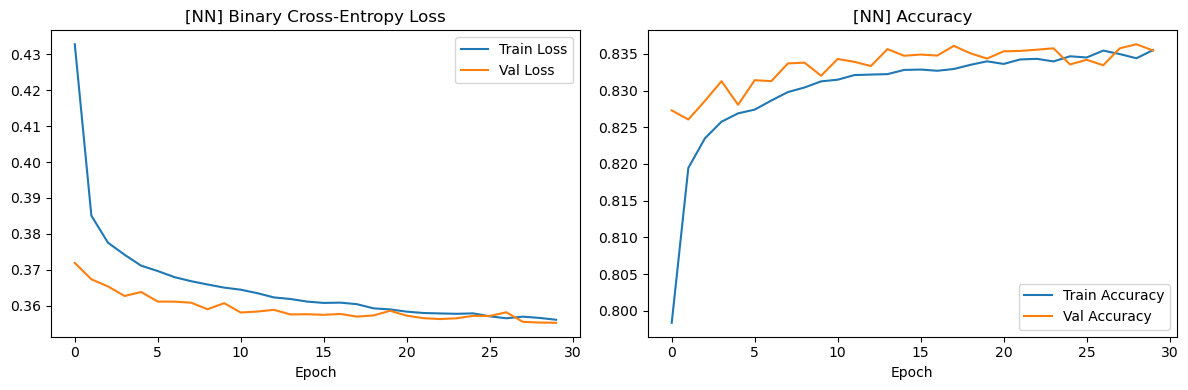

In [189]:
# ── [NN] Learning curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(nn_history.history['loss'],     label='Train Loss')
axes[0].plot(nn_history.history['val_loss'], label='Val Loss')
axes[0].set_title('[NN] Binary Cross-Entropy Loss')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(nn_history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(nn_history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('[NN] Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.show()

In [190]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight('balanced',
                               classes=np.array([0, 1]),
                               y=y_train)
cw = {0: weights[0], 1: weights[1]}
print("Class weights:", cw)

Class weights: {0: 1.6932243921881227, 1: 0.70951633375643}


# Logestic Regression!

In [191]:
t0 = time.time()

log_clf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

grid_log = GridSearchCV(
    estimator=log_clf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_log.fit(X_train_scaled, y_train)

best_log = grid_log.best_estimator_

print("Best Params:", grid_log.best_params_)
print("Best CV F1:", grid_log.best_score_)
print(f"Time: {time.time()-t0:.1f}s")

# ===== Validation =====
log_val_pred = best_log.predict(X_val_scaled)
log_val_prob = best_log.predict_proba(X_val_scaled)[:, 1]

print("\n=== Logistic Regression - Validation ===")
print("Accuracy:", accuracy_score(y_val, log_val_pred))
print("F1:", f1_score(y_val, log_val_pred))
print("AUC:", roc_auc_score(y_val, log_val_prob))
print(classification_report(y_val, log_val_pred))

# ===== Test =====
log_test_pred = best_log.predict(X_test_scaled)
log_test_prob = best_log.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression - Test ===")
print("Accuracy:", accuracy_score(y_test, log_test_pred))
print("F1:", f1_score(y_test, log_test_pred))
print("AUC:", roc_auc_score(y_test, log_test_prob))
print(classification_report(y_test, log_test_pred))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1: 0.8432743126047877
Time: 105.2s

=== Logistic Regression - Validation ===
Accuracy: 0.7942824188498929
F1: 0.8425036267687067
AUC: 0.8861523471374453
              precision    recall  f1-score   support

           0       0.61      0.83      0.70     10753
           1       0.91      0.78      0.84     25661

    accuracy                           0.79     36414
   macro avg       0.76      0.80      0.77     36414
weighted avg       0.83      0.79      0.80     36414


=== Logistic Regression - Test ===
Accuracy: 0.7920637100096114
F1: 0.8404013152348031
AUC: 0.8841218469639831
              precision    recall  f1-score   support

           0       0.61      0.83      0.70     10753
           1       0.92      0.78      0.84     25662

    accuracy                           0.79     36415
   macro avg       0.76      0.80      0.77     36415
weighted 

In [192]:
t0 = time.time()

rf_clf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf_clf,
    param_grid=rf_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print("Best Params:", grid_rf.best_params_)
print("Best CV F1:", grid_rf.best_score_)
print(f"Time: {time.time()-t0:.1f}s")

# ===== Validation =====
rf_val_pred = best_rf.predict(X_val_scaled)
rf_val_prob = best_rf.predict_proba(X_val_scaled)[:, 1]

print("\n=== Random Forest - Validation ===")
print("Accuracy:", accuracy_score(y_val, rf_val_pred))
print("F1:", f1_score(y_val, rf_val_pred))
print("AUC:", roc_auc_score(y_val, rf_val_prob))
print(classification_report(y_val, rf_val_pred))

# ===== Test =====
rf_test_pred = best_rf.predict(X_test_scaled)
rf_test_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

print("\n=== Random Forest - Test ===")
print("Accuracy:", accuracy_score(y_test, rf_test_pred))
print("F1:", f1_score(y_test, rf_test_pred))
print("AUC:", roc_auc_score(y_test, rf_test_prob))
print(classification_report(y_test, rf_test_pred))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV F1: 0.8101181640424612
Time: 536.4s


/Users/mahsadorri/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/mahsadorri/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



=== Random Forest - Validation ===
Accuracy: 0.805129895095293
F1: 0.856970087881964
AUC: 0.8853526612951717
              precision    recall  f1-score   support

           0       0.65      0.75      0.69     10753
           1       0.89      0.83      0.86     25661

    accuracy                           0.81     36414
   macro avg       0.77      0.79      0.78     36414
weighted avg       0.82      0.81      0.81     36414



/Users/mahsadorri/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/mahsadorri/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



=== Random Forest - Test ===
Accuracy: 0.801345599340931
F1: 0.8539530000807559
AUC: 0.882570811981407
              precision    recall  f1-score   support

           0       0.64      0.75      0.69     10753
           1       0.89      0.82      0.85     25662

    accuracy                           0.80     36415
   macro avg       0.76      0.79      0.77     36415
weighted avg       0.81      0.80      0.81     36415



In [193]:
from xgboost import XGBClassifier
t0 = time.time()


xgb_clf = XGBClassifier(
    random_state=42,
    n_jobs=-1,
)

xgb_param_grid = {
    "n_estimators": [300],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],

}

grid_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best Params:", grid_xgb.best_params_)
print("Best CV F1:", grid_xgb.best_score_)
print(f"Time: {time.time()-t0:.1f}s")

# ===== Validation =====
xgb_val_pred = best_xgb.predict(X_val)
xgb_val_prob = best_xgb.predict_proba(X_val)[:, 1]

print("\n=== XGBoost - Validation ===")
print("Accuracy:", accuracy_score(y_val, xgb_val_pred))
print("F1:", f1_score(y_val, xgb_val_pred))
print("AUC:", roc_auc_score(y_val, xgb_val_prob))
print(classification_report(y_val, xgb_val_pred))

# ===== Test =====
xgb_test_pred = best_xgb.predict(X_test)
xgb_test_prob = best_xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost - Test ===")
print("Accuracy:", accuracy_score(y_test, xgb_test_pred))
print("F1:", f1_score(y_test, xgb_test_pred))
print("AUC:", roc_auc_score(y_test, xgb_test_prob))
print(classification_report(y_test, xgb_test_pred))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
Best CV F1: 0.8831727228465344
Time: 187.6s

=== XGBoost - Validation ===
Accuracy: 0.8360795298511562
F1: 0.8853328210546537
AUC: 0.9014293331411318
              precision    recall  f1-score   support

           0       0.74      0.69      0.71     10753
           1       0.87      0.90      0.89     25661

    accuracy                           0.84     36414
   macro avg       0.81      0.79      0.80     36414
weighted avg       0.83      0.84      0.83     36414


=== XGBoost - Test ===
Accuracy: 0.8308938624193327
F1: 0.881608797631407
AUC: 0.8987890893717274
              precision    recall  f1-score   support

           0       0.73      0.68      0.70     10753
           1       0.87      0.89      0.88     25662

    accuracy                           0.83     36415
   macro avg       0.80      0.79      0.79     36415
weighted avg       

In [194]:
# import sys
# !{sys.executable} -m pip install xgboost